In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


1.  **S no.**: Sequence Number
2.  **age**: The age of the patient
3. **creatinine phosphokinase**: Level of the CPK enzyme in the blood (mcg/L). Elevated levels of this enzyme often indicate damage to muscle tissue, including the heart muscle.
4. **diabetes**: Boolean flag indicating if the patient has diabetes (0 = No, 1 = Yes).
5. **ejection fraction**: A measurement, expressed as a percentage (%), of how much blood the left ventricle pumps out with each contraction. A normal heart pumps at 50% or higher. Lower values strongly indicate heart failure.
6. **high bp**：Boolean flag indicating if the patient has hypertension (0 = No, 1 = Yes).
7. **platelets**：Platelet count in the blood (kiloplatelets/mL).
8. **serum creatinine**: Level of serum creatinine in the blood (mg/dL). This is a primary indicator of kidney function. Severe heart failure often leads to kidney impairment, causing this value to rise.
9. **sex**:The gender of the patient (0 = Female, 1 = Male).
10. **smoking**: Boolean flag indicating if the patient actively smokes (0 = No, 1 = Yes).
11. **death**: Boolean flag indicating whether the patient died during the follow-up period (0 = Survived, 1 = Deceased).

------ missing data ------
age                         0
anaemia                     0
creatinine phosphokinase    0
diabetes                    0
ejection fraction           0
high bp                     0
platelets                   0
serum creatinine            0
sex                         0
smoking                     0
death                       0
dtype: int64


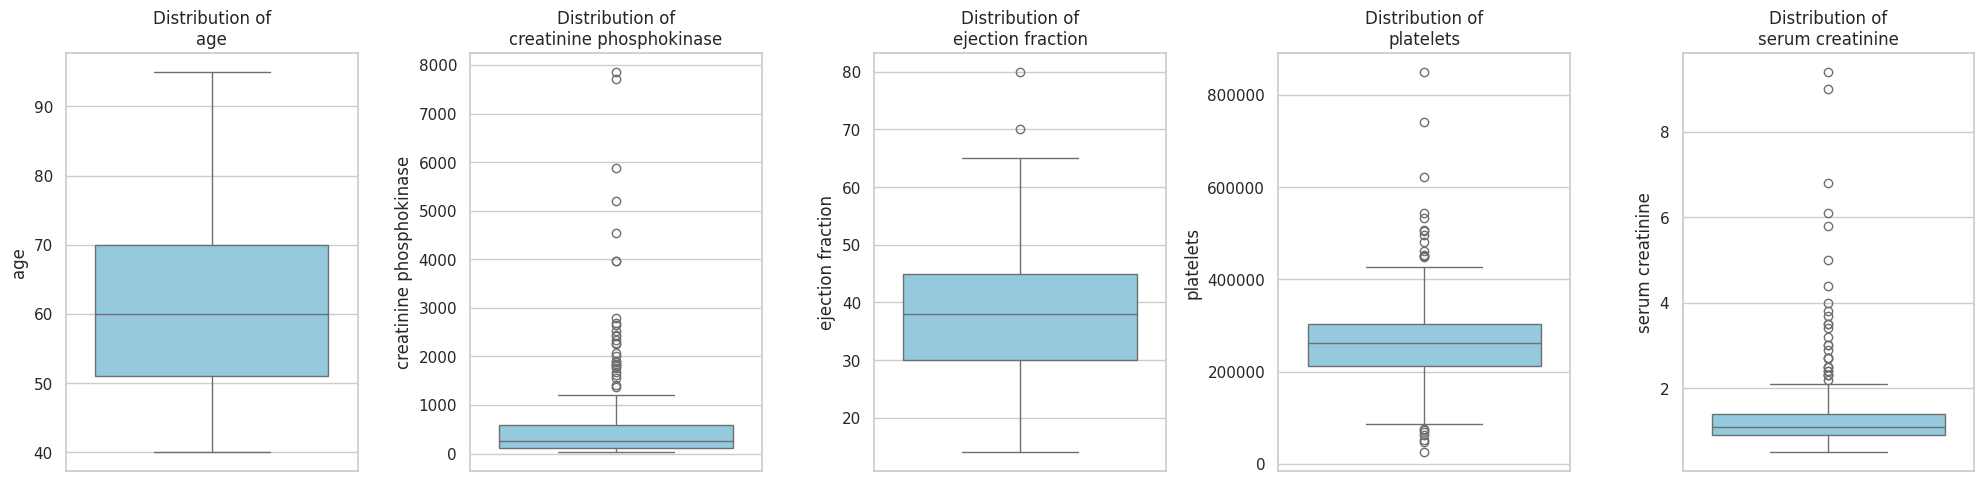

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SP/Heart_Failure_Details.csv')

if 'S no.' in df.columns:
    df.set_index('S no.', inplace=True)

categorical_features = ['anaemia', 'diabetes', 'high bp', 'sex', 'smoking']
numeric_features = ['age', 'creatinine phosphokinase', 'ejection fraction', 'platelets', 'serum creatinine']
target = 'death'

# check for missing data and outliers
print("------ missing data ------")
print(df.isnull().sum())

# Outliers
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of\n{col}')

plt.tight_layout()
plt.show()

1. Age: Patients are predominantly around 60 years old, with no obvious outliers in the distribution. The overall cohort is middle-aged and elderly, consistent with the high-risk population for heart failure.
2. Creatinine Phosphokinase: Most patients have low CPK levels, but there are a large number of high-value outliers, indicating that a small number of patients show significant signs of muscle (including myocardial) damage.
3. Ejection Fraction: The median is approximately 40%, far below the normal range of 50%-70%, demonstrating that the heart failure patients in the dataset generally have severely impaired cardiac pumping function.
4. Platelets: The median falls within the normal range, with concentrated data distribution and only a small number of low-value outliers.
5. Serum Creatinine: The median is slightly above the normal range, accompanied by a large number of high-value outliers, suggesting that some patients have renal function abnormalities, with a few cases being particularly severe.

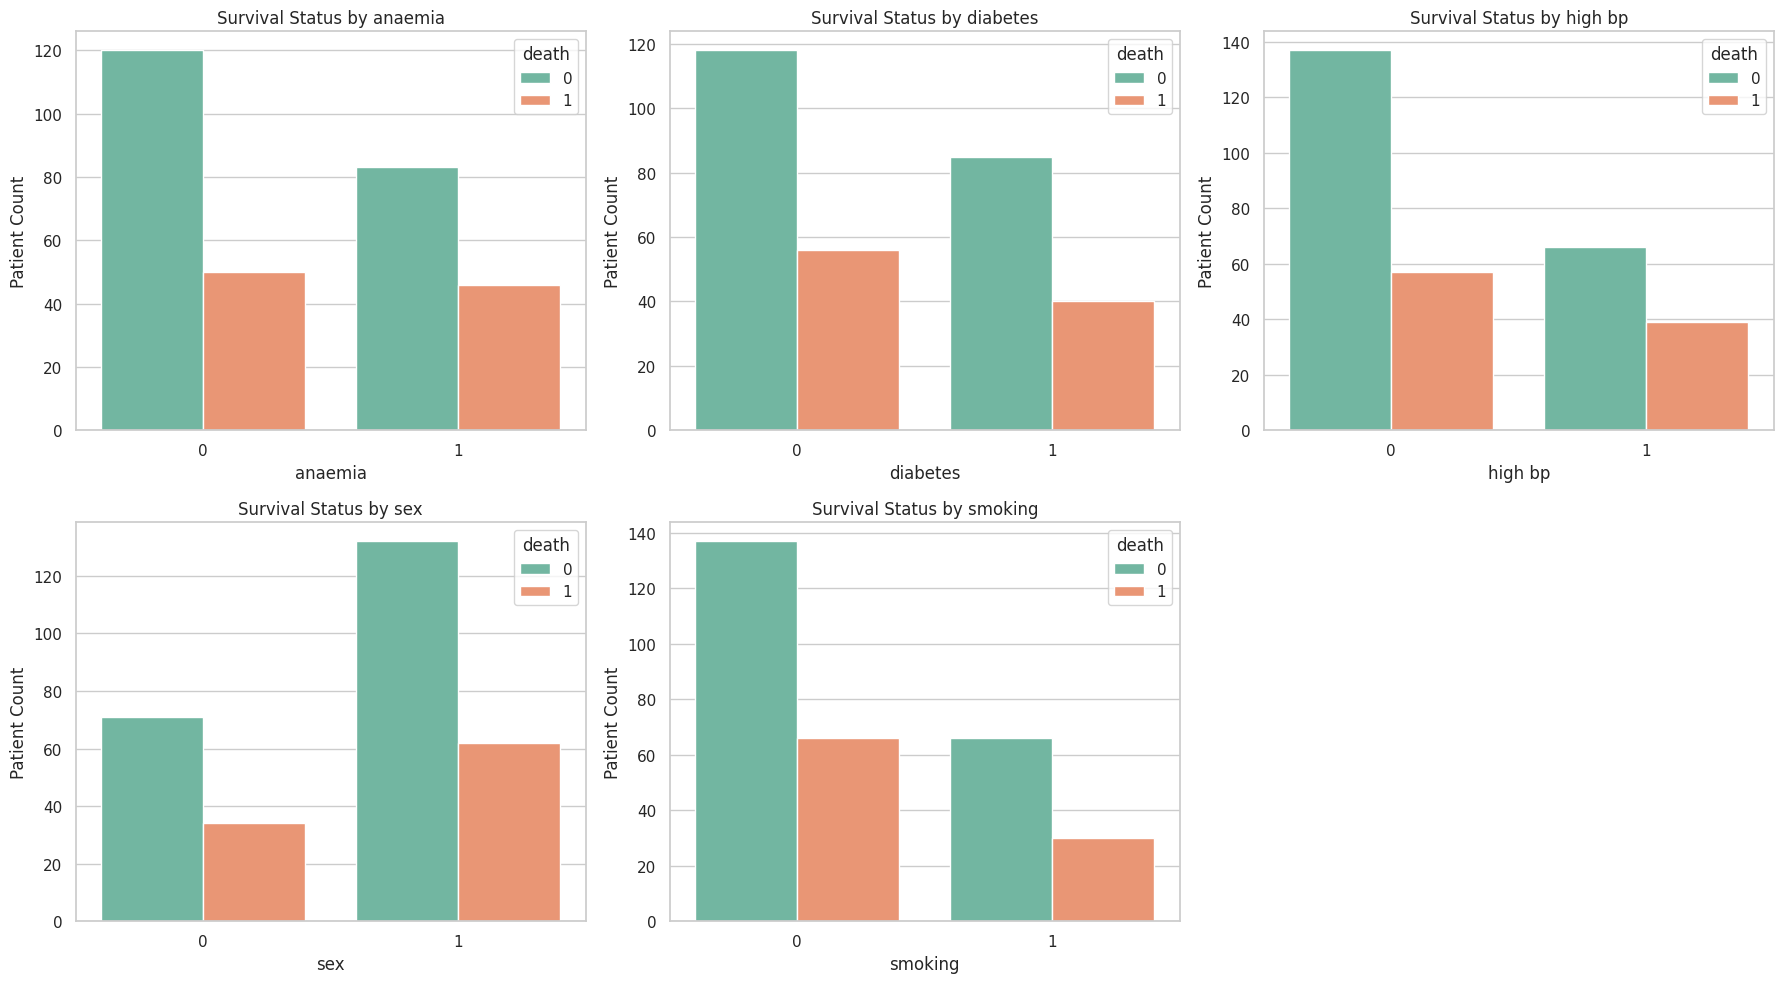

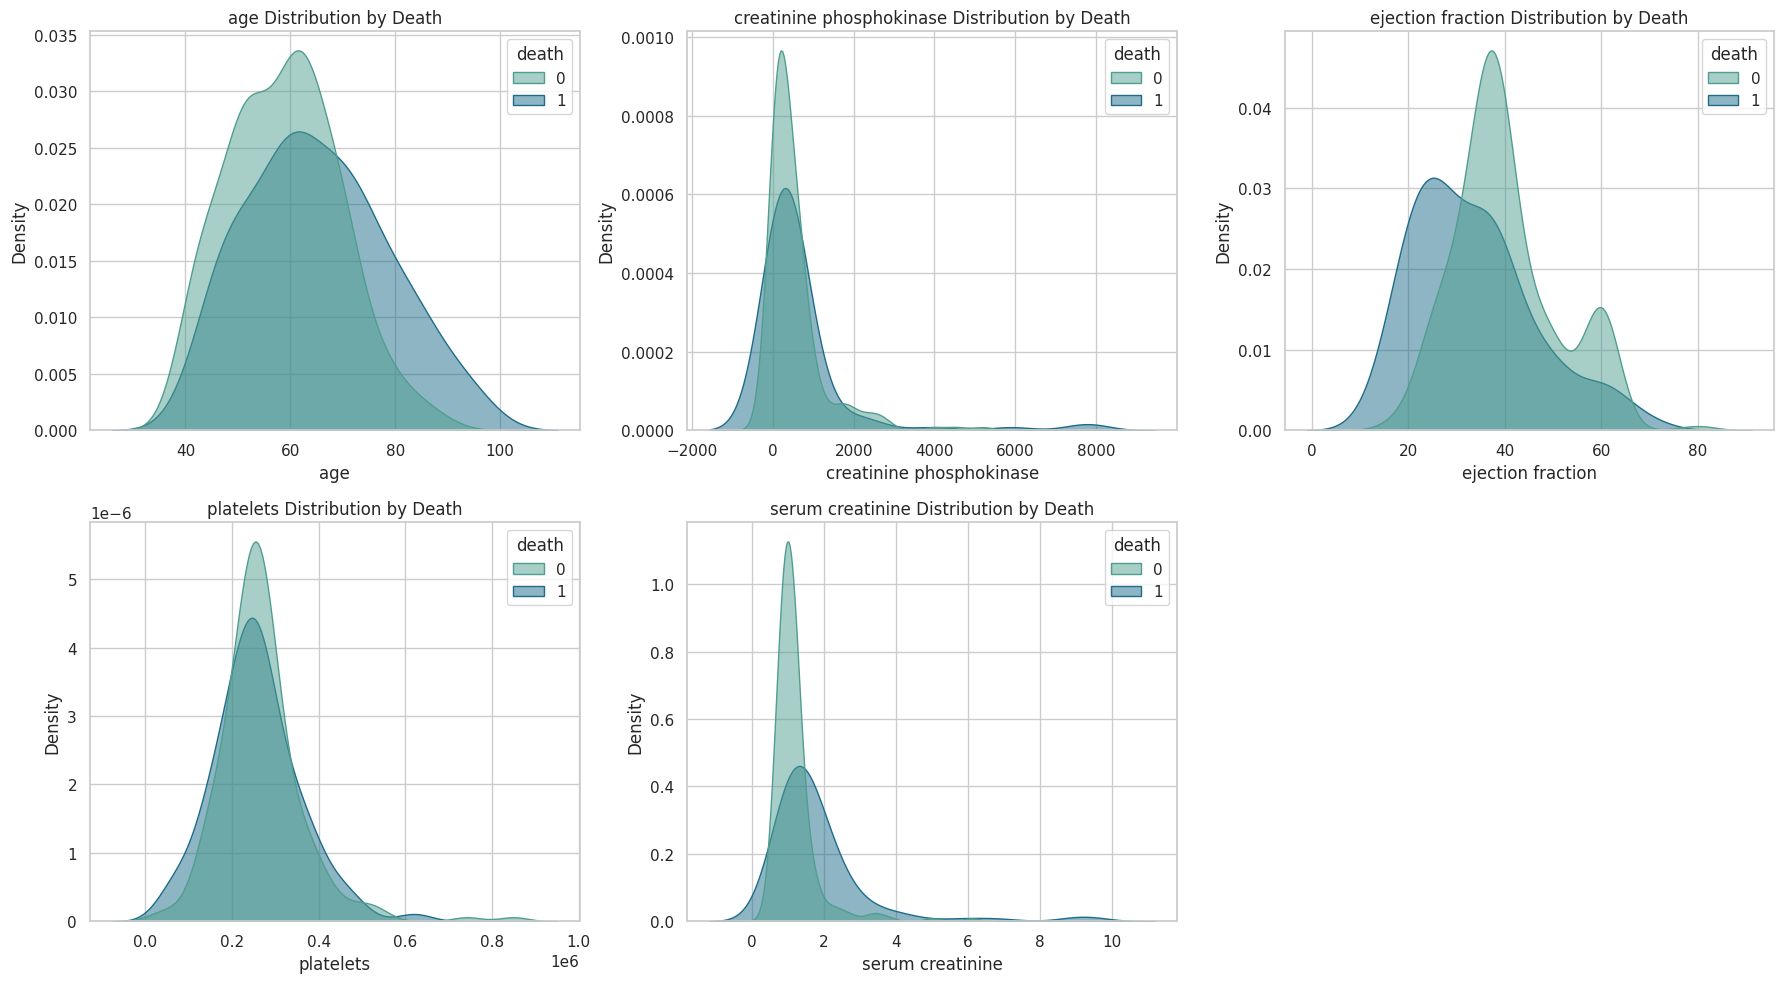

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Survival Status by {col}')
    axes[i].set_ylabel('Patient Count')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='crest', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Death')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()



1. Anaemia, high blood pressure, diabetes, sex, and smoking: There is no significant difference in the number of deaths across groups, indicating that these underlying chronic conditions, gender, and smoking habits have limited impact on prognosis and weak discriminative power.
2.
*  Age: The death group has a higher peak at an older age, showing that advanced age significantly increases mortality risk.
*  Ejection Fraction: The peak of the death group is far lower than that of the survival group, making it the most critical indicator: the lower the cardiac pumping function, the higher the mortality risk.
*  Serum Creatinine: The death group has more high-value outliers, suggesting that worse renal function is associated with higher risk.
* CPK and Platelets: The distributions of the two groups are highly overlapping, with no obvious discriminative power for survival status.



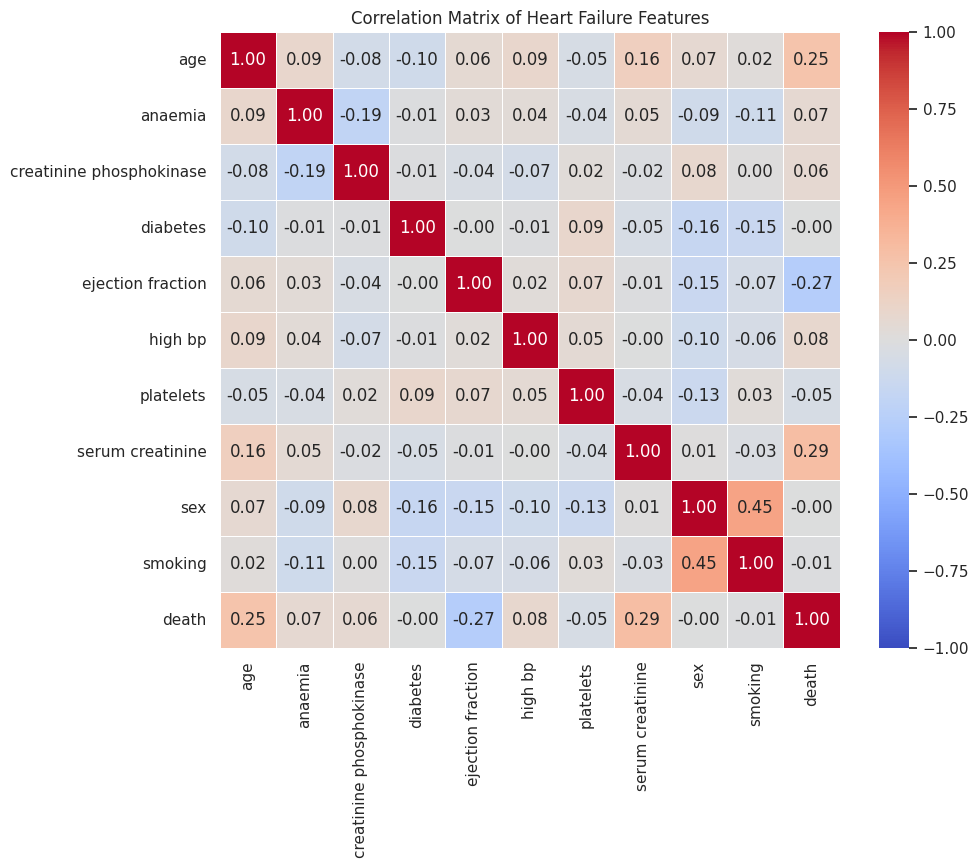

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Heart Failure Features')
plt.show()

Standardization: Since "platelets" has huge numbers (in the hundreds of thousands) and "serum creatinine" is tiny (single digits), must standardize the numerical features. This prevents the model from being thrown off by the giant numbers.

Skip Encoding: The categorical variables (like sex, smoking, and diabetes) are already perfectly formatted as 0s and 1s. You don't need to bother with complex One-Hot Encoding—just feed these columns straight into the model.

**Limited Impact of Underlying Conditions**: Common chronic morbidities such as smoking, hypertension, and diabetes, as well as lifestyle factors, are not the direct leading contributors to short-term mortality in this sample.

The true determinants of patient survival outcomes lie in three key physiological/biochemical indicators:
1. **Extremely low ejection fraction** (severe cardiac pump failure)
2. **Advanced age** (especially in those over 70 years old)
3. **Abnormally high serum creatinine** (heart failure complicated by severe renal failure)
